# Implicit Funciton toolboox for geophysics

If we can fit a point data to an Implicit Neural Network, we can operate directly on the Neural Network representation.

In [1]:
%load_ext autoreload

%autoreload 2

import functools
import random
from pathlib import Path

import colorcet as cc
import comet_ml
import matplotlib.pyplot as plt
import numpy as np
import optuna
import torch
from tqdm.auto import tqdm

from datasets import PointData3D, NCDataset, merge_z_slices, construct_xyz
from models import RLoss, Siren
from models import get_INR as wire
from utils import query_inr, query_inr_batched, plt_inr, plt_cntr, plt_3d

torch.manual_seed(seed := 0)
random.seed(seed)

rng = np.random.default_rng()

if torch.cuda.is_available():
    device = "cuda"


In [2]:
netcdf_path = Path("data/P864-line-magnetic-AWAGS_MAG_2010.nc")
dataset = NCDataset(netcdf_path, variable="mag_tieLevelled")
dataset.split_train_val(train_pct=0.75)

dict_keys(['line_index', 'line', 'bearing', 'dateCode', 'levelFlag', 'lineType', 'survey', 'FID', 'altitude', 'flight', 'mag_awagsLevelled', 'mag_microLevelled', 'mag_tieLevelled', 'y', 'x', 'transverse_mercator'])


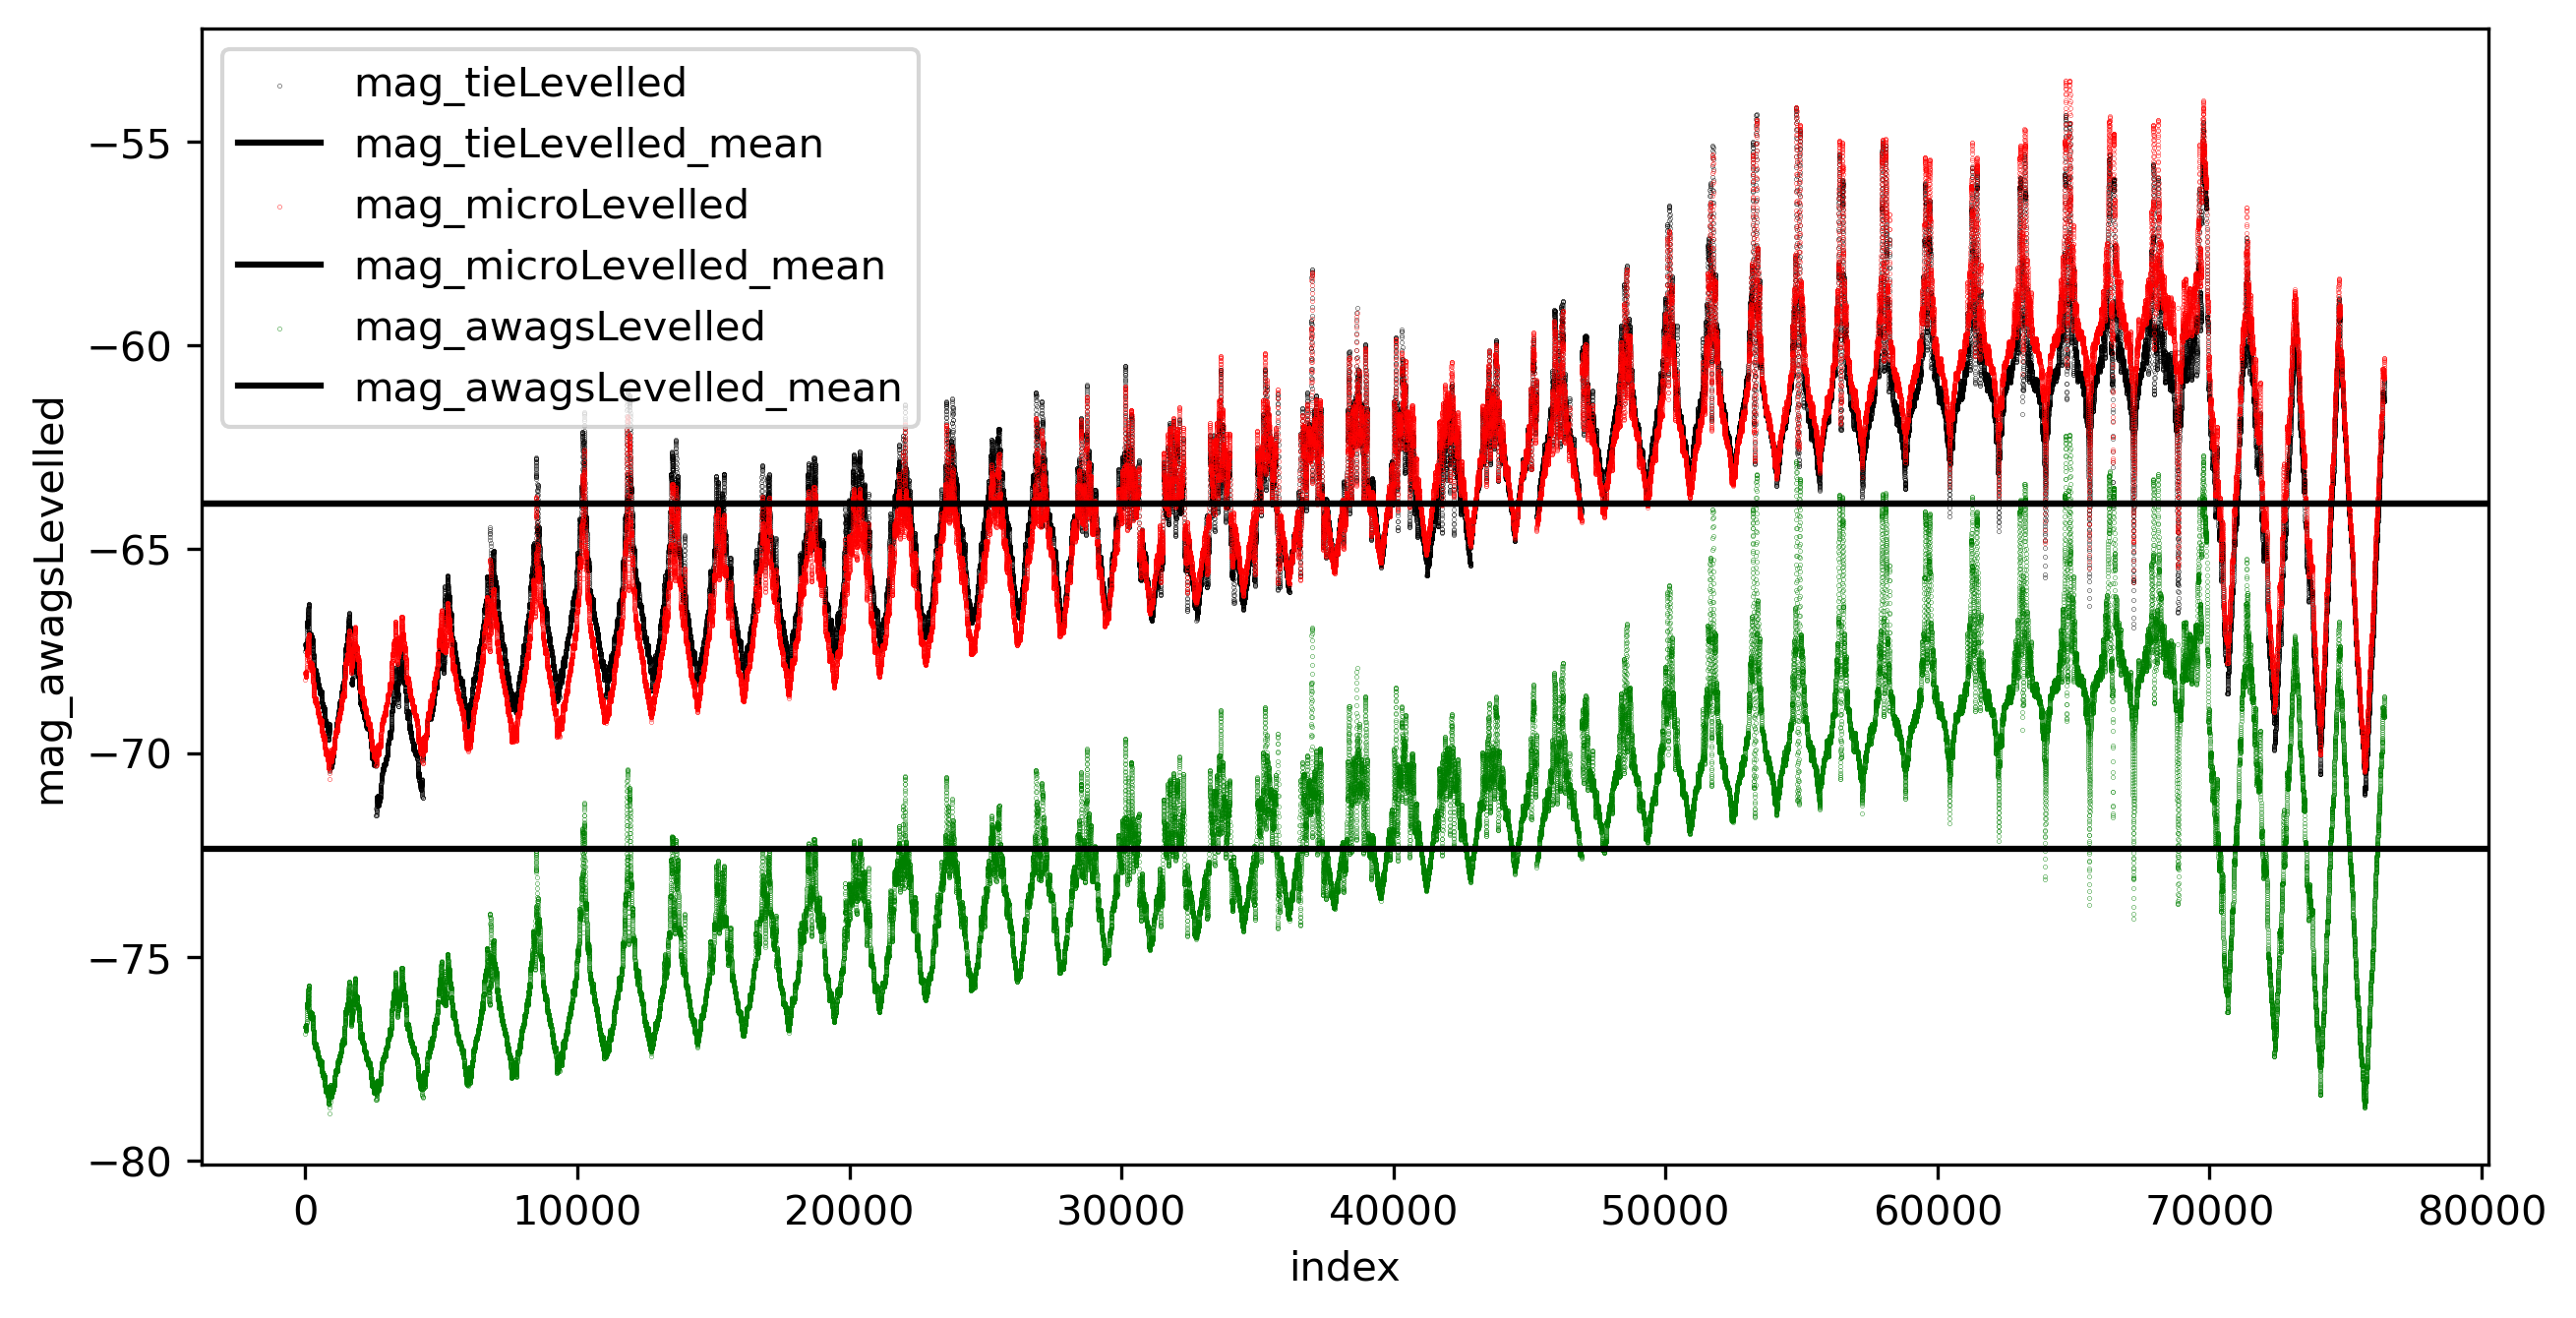

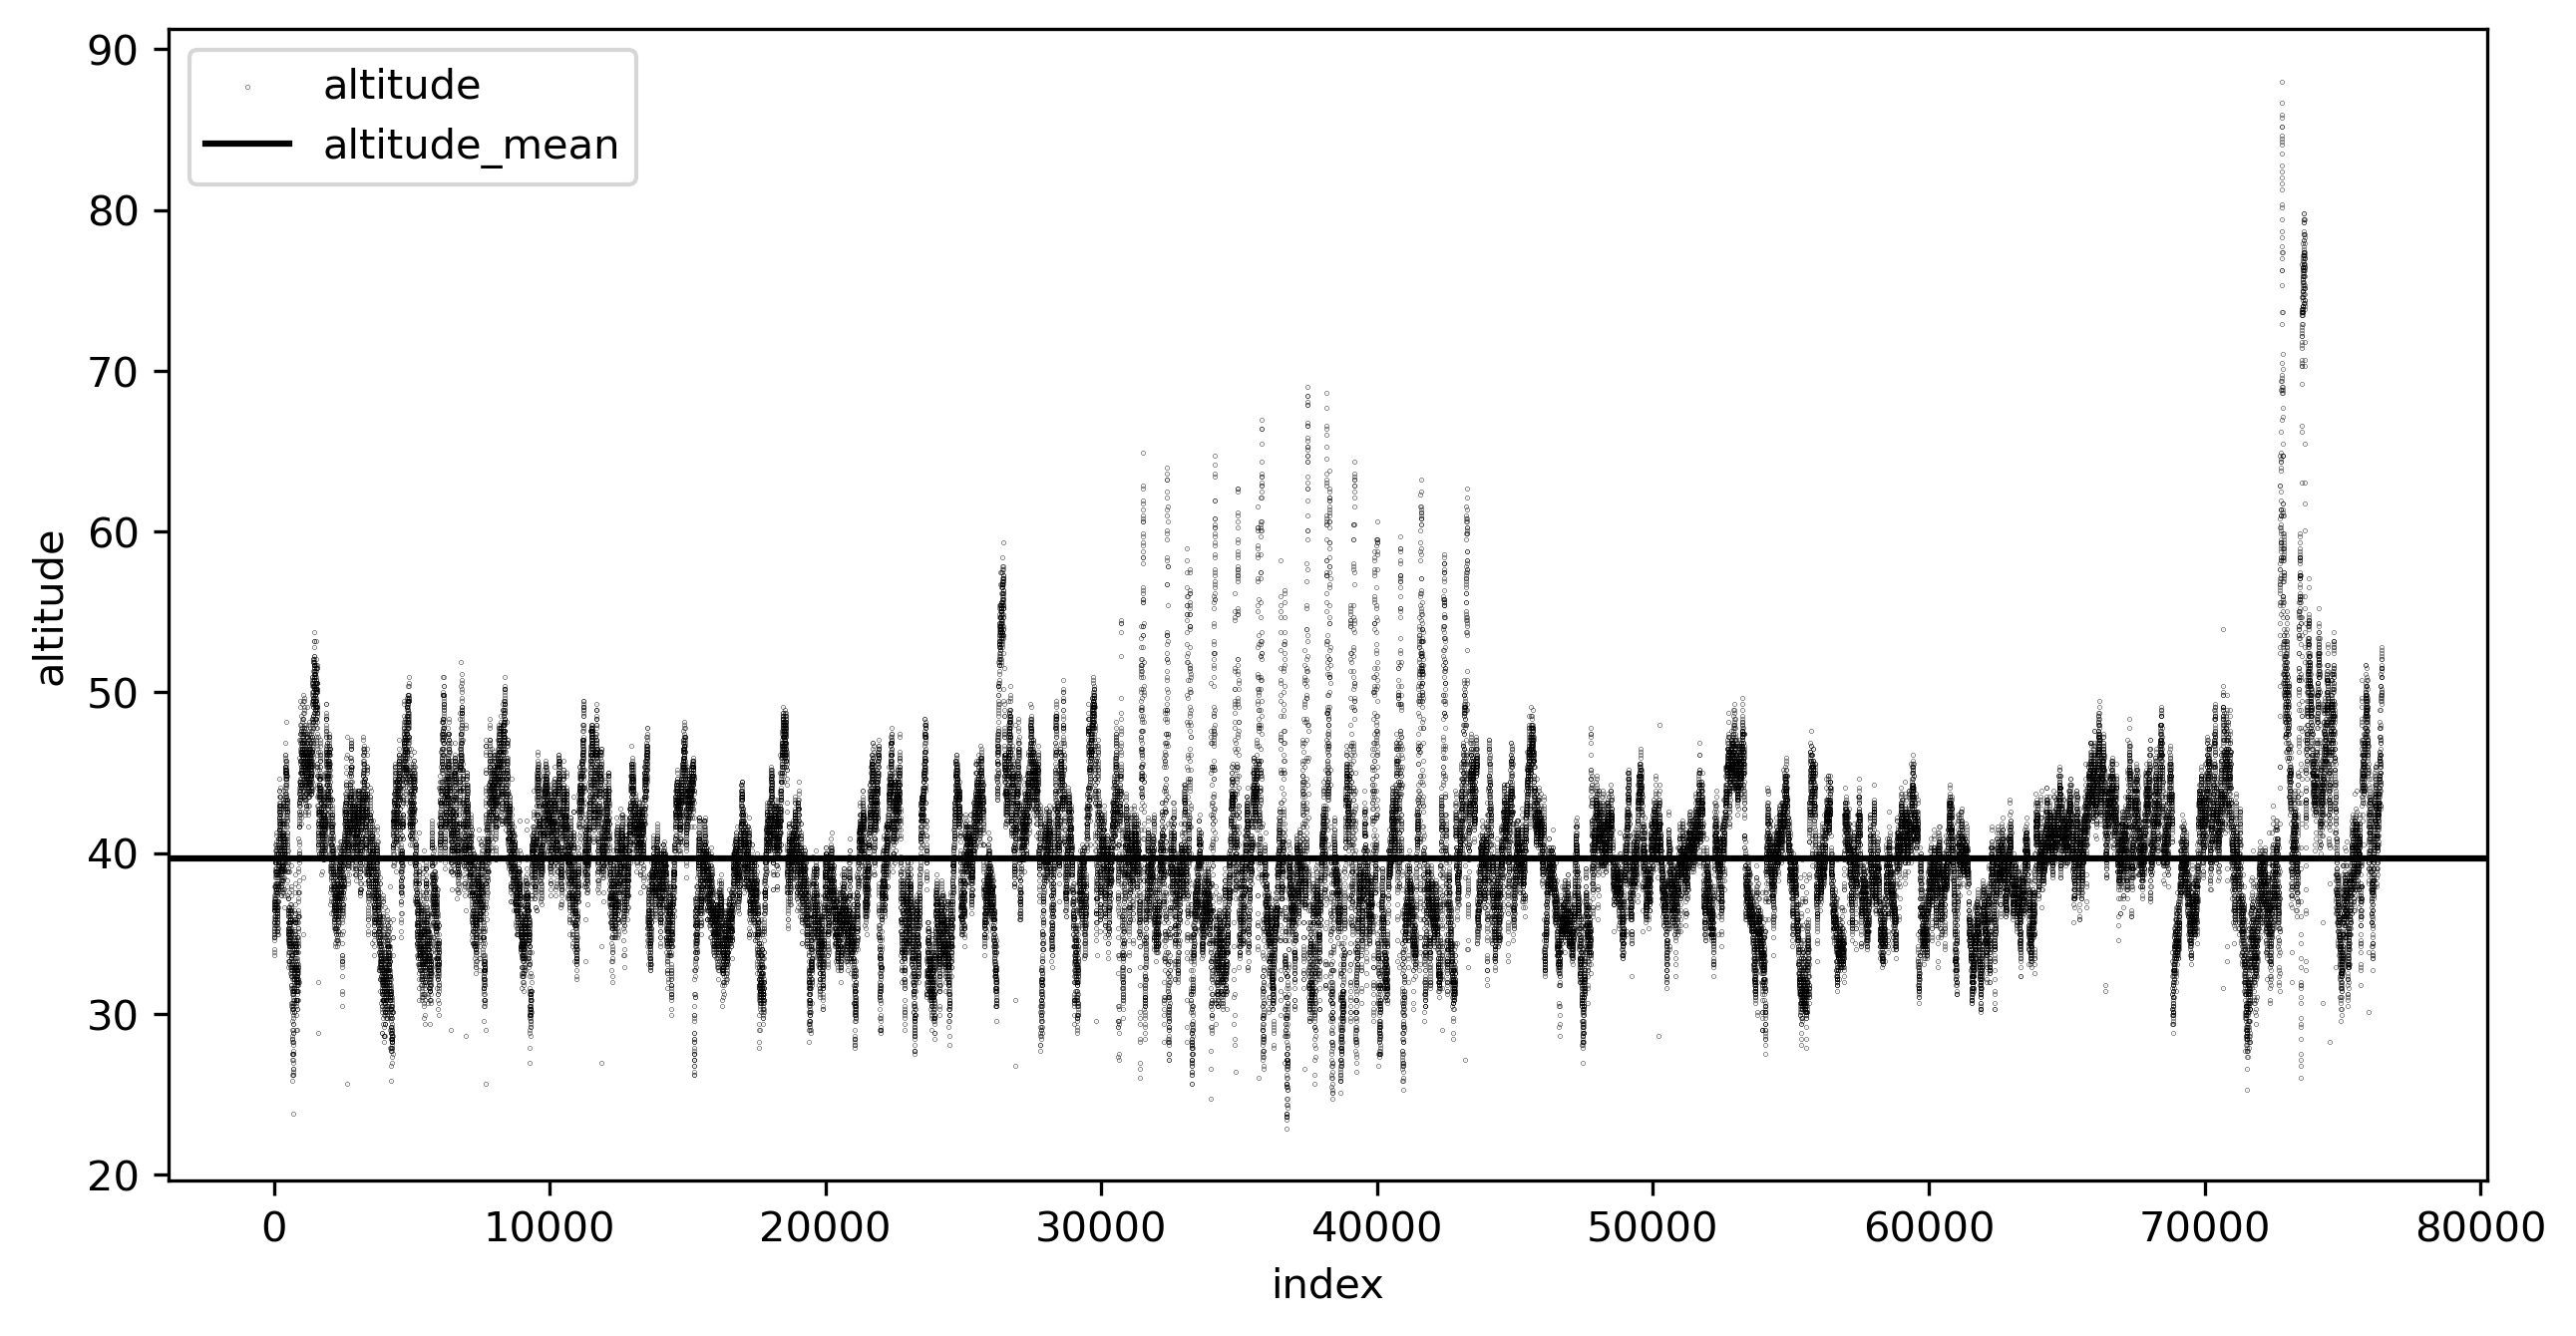

In [3]:
print(dataset.ncd.variables.keys())
dataset.plot_variables(
    ["mag_tieLevelled", "mag_microLevelled", "mag_awagsLevelled"], s=0.01, dpi=300
)
# "microlevelling removes low amplitude flight line noise after tie line levelling."
dataset.plot_variables(["altitude"], s=0.01, dpi=300)

In [4]:
def train(f, dataset, opt, exp: comet_ml.Experiment = None, trial: optuna.Trial = None):
    f.train()

    optim = torch.optim.Adam(lr=opt["initial_lr"], params=f.parameters())
    sched = torch.optim.lr_scheduler.OneCycleLR(
        optim,
        steps_per_epoch=1,
        epochs=opt["total_steps"],
        max_lr=opt["initial_lr"],
    )

    cri_mse = torch.nn.MSELoss()
    if opt["weight_rloss"] > 0:
        cri_r = RLoss(Sigma=opt["rloss_Sigma"])
        if exp is not None:
            exp.add_tag("RLoss")

    d = dataset[0]

    train_xyz = d["train_xyz"].to(device, non_blocking=True).unsqueeze(0)
    train_u = d["train_u"].to(device, non_blocking=True).unsqueeze(0)
    val_xyz = d["val_xyz"].to(device, non_blocking=True).unsqueeze(0)
    val_u = d["val_u"].to(device, non_blocking=True).unsqueeze(0)

    for step in tqdm(range(opt["total_steps"])):
        if exp is not None:
            exp.set_epoch(step)
            exp.set_step(step)

        with torch.amp.autocast(
            opt["device"], dtype=torch.float16, enabled=opt["use_amp"]
        ):
            pred_u, gt_xyz = f(train_xyz)

            loss_mse = cri_mse(pred_u, train_u)

            if opt["weight_rloss"] > 0:
                xbar = torch.rand_like(train_xyz[:, : opt["n_samples"], :])
                loss_r = cri_r(f, xbar, opt["n_samples"])

                loss_total = loss_mse + opt["weight_rloss"] * loss_r
            else:
                loss_total = loss_mse

            if exp is not None:
                exp.log_metric("Loss Total", loss_total.item())
                exp.log_metric("Loss MSE", loss_mse.item())
                if opt["weight_rloss"] > 0:
                    exp.log_metric("Loss Regularisation", loss_r.item())
            if trial is not None:
                trial.report(loss_total.item(), step)

        optim.zero_grad(set_to_none=True)
        loss_total.backward()
        optim.step()
        sched.step()

        if exp is not None and trial is not None:
            exp.log_parameter("lr", sched.get_last_lr())
            if trial.should_prune():
                exp.add_tag("Pruned")
                exp.end()
                raise optuna.TrialPruned()

    def val():
        f.eval()
        cri_mae = torch.nn.L1Loss()
        with torch.no_grad():
            pred_val_u, _ = f(val_xyz)
            val_metric = cri_mae(pred_val_u, val_u)

        return val_metric

    val_metric = val()

    if exp is not None:
        exp.log_metric("Val Loss", val_metric.item())

        def _comet_plot():
            cells, extent, height = query_inr(
                dataset, f, i=0, z_mod=-dataset[0]["train_coords"][:, 2].mean()
            )
            ax_args = dict(cmap=cc.cm.CET_L1, vmin=-70, vmax=-55)
            fig = plt_inr(
                cells,
                extent,
                height,
                ax_args,
                gt_tiff=r"/home/luke/PhD/ch3/implicitgeo/data/P864-grid-tmi.tif",
                figsize=(8, 4),
                dpi=80,
            )
            return fig

        fig = _comet_plot()
        exp.log_figure(netcdf_path.stem, figure=fig, step=step)
        exp.end()

    return f, val_metric


def objective(trial: optuna.Trial, dataset, device):
    train_opts = dict(
        total_steps=500,  # steps = epochs in INR
        device=device,
        use_amp=False,
        nonlinearity="sinusoidal",
        n_samples=int(0.1 * dataset.cells.shape[0]),  # 10% samples for RLoss
        initial_lr=trial.suggest_float(
            "initial_lr", 4e-5, 4e-5, log=True
        ),  # WIRE needs 10-100 x larger LR?
        weight_rloss=0.01,  # trial.suggest_float("weight_rloss", 1e-6, 2e-3, log=True),
        rloss_Sigma=1e-4,  # trial.suggest_float("rloss_Sigma", 1e-6, 4e-4, log=True),
        hidden_layers=trial.suggest_int("hidden_layers", 3, 3),
        omega_0=trial.suggest_float("omega_0", 10, 30, step=10),
        sigma=trial.suggest_float("sigma", 10, 30, step=10),
        # omega_0=trial.suggest_float("omega_0", 1, 100, step=5),
        # sigma=trial.suggest_float("sigma", 1, 100, step=5),
    )

    f = None  # Ensure model is refreshed each trial

    if "sinusoidal" in train_opts["nonlinearity"]:
        comet_tags = ["SIREN"]

        f = Siren(
            in_features=3,
            out_features=1,
            hidden_features=256,
            hidden_layers=train_opts["hidden_layers"],
            outermost_linear=True,
        )
    elif "wire" in train_opts["nonlinearity"]:
        comet_tags = ["WIRE"]

        f = wire(
            nonlin=train_opts["nonlinearity"],  # "wire2d" | "wire3d"
            in_features=3,
            out_features=1,
            hidden_features=256,
            hidden_layers=train_opts["hidden_layers"],
            first_omega_0=train_opts["omega_0"],  # first Frequency of sinusoid
            hidden_omega_0=train_opts["omega_0"],  # hidden Frequency of sinusoid
            scale=train_opts["sigma"],  # Sigma of Guassian
            pos_encode=False,
            sidelength=None,  # only for pos_encode
        )
        # print(model_wire)

    f = f.to(device, non_blocking=True)

    exp = comet_ml.Experiment(disabled=False)
    exp.add_tags(comet_tags)
    exp.log_code("models.py")
    exp.log_parameters(train_opts)

    _, metric = train(f, dataset, train_opts, exp, trial)

    return metric

In [5]:
if tune := 0:
    objective = functools.partial(objective, dataset=dataset, device=device)

    study = optuna.create_study(
        study_name="geoinr_test",
        direction="minimize",
        # pruner=optuna.pruners.ThresholdPruner(upper=0.1, n_warmup_steps=100),
        storage="sqlite:///inr.db",
        load_if_exists=True,
    )
    study.optimize(objective, n_trials=1)

In [6]:
# Recreate Best Models
netcdf_path = Path(
    "/home/luke/PhD/ch3/implicitgeo/data/P864-line-magnetic-AWAGS_MAG_2010.nc"
)
dataset = NCDataset(netcdf_path, "mag_microLevelled")
dataset.split_train_val(train_pct=0.8)

train_opts = dict(
    total_steps=1000,
    device=device,
    use_amp=False,
    n_samples=int(0.1 * dataset.xyz.shape[0]),
    initial_lr=5e-4,
    weight_rloss=1e-4,
    rloss_Sigma=1e-6,
    hidden_layers=4,
    nonlinearity="sinusoidal",
)

best_model_siren = Siren(
    in_features=3,
    out_features=1,
    hidden_features=256,
    hidden_layers=train_opts["hidden_layers"],
    outermost_linear=True,
)

best_model_wire = wire(
    nonlin=train_opts["nonlinearity"],
    in_features=3,
    out_features=1,
    hidden_features=256,
    hidden_layers=3,
    first_omega_0=10.0,
    hidden_omega_0=10.0,
    scale=20.0,  # Sigma
)

f = best_model_siren  # u = f(x,y,z)
inr, val_metric = train(f.to(device, non_blocking=True), dataset, train_opts)
# f becomes implicit neural representation when trained
print(f"Val MAE: {val_metric}")

  0%|          | 0/1000 [00:00<?, ?it/s]

Val MAE: 0.005303836893290281


TypeError: Invalid shape (350, 350, 350) for image data

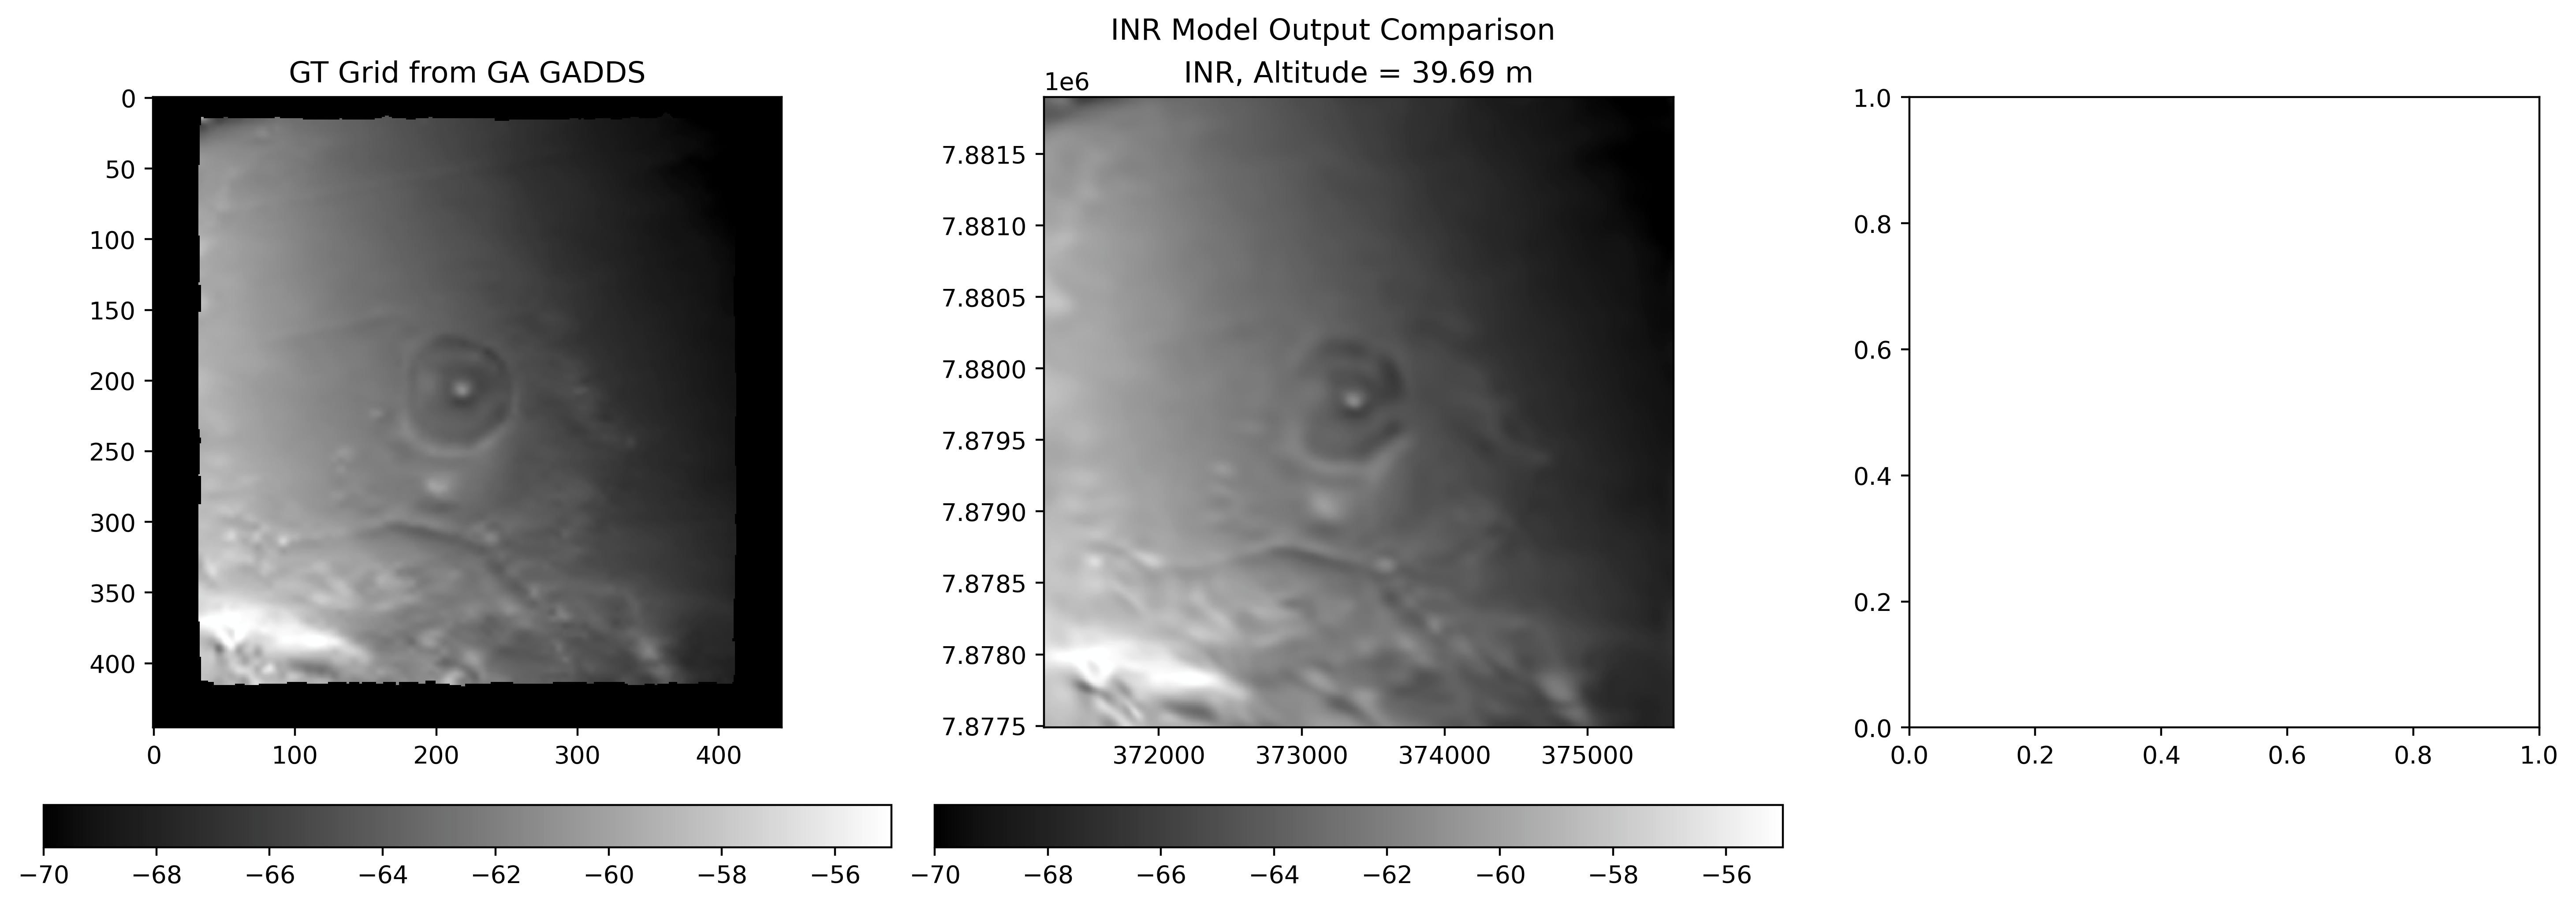

In [7]:
altitude = dataset.ncd.variables["altitude"][:].mean()
z = dataset.normalise(altitude, "z")

u = query_inr(inr, shape=(445, 445, 1), z_mod=z)

unnormalise_fn = dataset.unnormalise
if unnormalise_fn is not None:
    u = unnormalise_fn(u, "u")
    extent = [
        unnormalise_fn(-1, "x"),
        unnormalise_fn(1, "x"),
        unnormalise_fn(-1, "y"),
        unnormalise_fn(1, "y"),
    ]
    altitude = unnormalise_fn(z, "z")
else:
    extent = [-1, 1, -1, 1]
    altitude = 0

ax_args = dict(cmap=cc.cm.CET_L1, vmin=-70, vmax=-55)

fig = plt_inr(
    u,
    extent,
    altitude,
    ax_args,
    i=0,
    _vmin=-5,
    _vmax=5,
    gt_tiff=r"/home/luke/PhD/ch3/implicitgeo/data/P864-grid-tmi.tif",
    figsize=(15, 5),
    dpi=400,
)

In [8]:
shape = (445, 445, 25)
full_u = []

for i, b_u in enumerate(
    query_inr_batched(
        inr,
        shape=shape,
        chunksize=256_000,
        z_mod=dataset.normalise(altitude, "z"),
    )
):
    full_u.append(b_u.squeeze())

full_u = torch.hstack(full_u).view(shape).rot90().permute(2, 0, 1).numpy()

In [ ]:
import tifffile

gtt = tifffile.imread(r"/home/luke/PhD/ch3/implicitgeo/data/P864-grid-tmi.tif")

for i, u in enumerate(full_u):
    z = torch.linspace(z - 1, z + 1, steps=shape[2])[i]
    plt_inr(
        u,
        extent,
        dataset.unnormalise(z, "z"),
        ax_args,
        # i=0,
        # _vmin=-5,
        # _vmax=5,
        gt_tiff=r"/home/luke/PhD/ch3/implicitgeo/data/P864-grid-tmi.tif",
        figsize=(15, 5),
        dpi=400,
    )
    plt.show()

(370975.803125, 375822.196875, 7877268.1, 7882116.9)

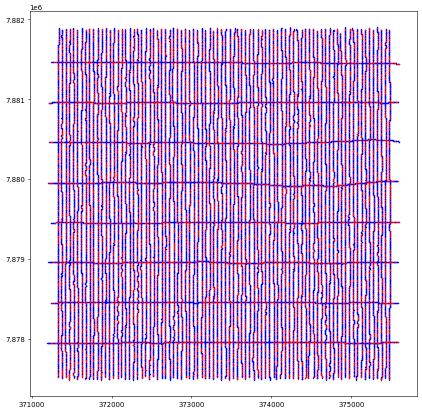

In [13]:
d = dataset[0]

plt.figure(figsize=(10, 10), dpi=50)
plt.scatter(
    dataset.unnormalise(d["train_xyz"][:, 0], "x"),
    dataset.unnormalise(d["train_xyz"][:, 1], "y"),
    s=1,
    facecolors="b",
    edgecolors="b",
)
plt.scatter(
    dataset.unnormalise(d["val_xyz"][:, 0], "x"),
    dataset.unnormalise(d["val_xyz"][:, 1], "y"),
    s=1,
    facecolors="r",
    edgecolors="r",
)
plt.axis("equal")
# plt.axis([372000, 373000, 7.879 * 1e6, 7.880 * 1e6])

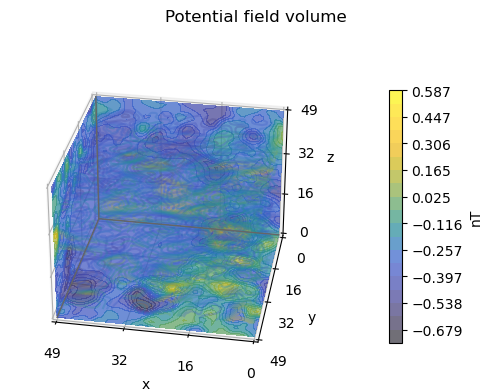

In [16]:
u_vol = query_inr(inr, shape=(50, 50, 50))
plt_3d(u_vol, ori="z", levels=20, step=5, elev=30, azim=100, linear_width=1, alpha=0.3)

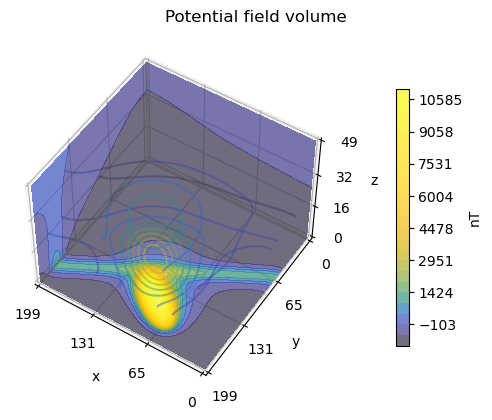

In [17]:
# Noddyverse Synthetic Comparison
plt_3d(
    u=merge_z_slices(Path("/home/luke/PhD/ch3/implicitgeo/data"), idx=0),
    ori="z",
    step=20,
    elev=50,
    azim=123,
    linear_width=1000,
    cmap=cc.cm.CET_L20,
    alpha=0.5,
)

Explicit function: $$u(x,y,z) = \sin(x+y+z) + \cos(x-y-z)$$

Explicit x, y, z partial derivatives:
$$\frac{\partial{u(x,y,z)}}{\partial{x}} = \cos(x+y+z) - \sin(x-y-z)$$ 
$$\frac{\partial{u(x,y,z)}}{\partial{y}} = \cos(x+y+z) + \sin(x-y-z)$$
$$\frac{\partial{u(x,y,z)}}{\partial{z}} = \cos(x+y+z) + \sin(x-y-z)$$

In [18]:
## Custom Function sample:
# TODO make a custom geophysical test grid with just a box.
def cust_f(d=200, a=1, l=1):
    x, y, z = np.meshgrid(
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        indexing="xy",
    )
    u = a * (np.sin(x + y + z) + np.cos(x - y - z))
    return (x, y, z, u)


def cust_df(d=200, a=1, l=1):
    x, y, z = np.meshgrid(
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        np.linspace(-l, l, d),
        indexing="xy",
    )
    dudx = a * (np.cos(x + y + z) - np.sin(x - y - z))
    dudy = a * (np.sin(x - y - z) + np.cos(x + y + z))
    dudz = a * (np.sin(x - y - z) + np.cos(x + y + z))

    return (dudx, dudy, dudz)

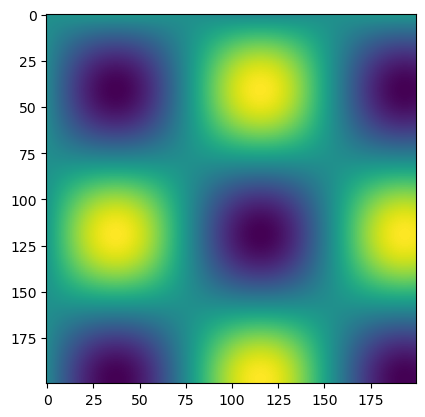

In [19]:
a = 1
l = 4
x, y, z, u = cust_f(d=200, a=a, l=l)
dudx, dudy, dudz = cust_df(d=50, a=a, l=l)
plt.imshow(u[25])
# plt_3d(u, ori="z", step=50, elev=33, azim=120, linear_width=1, alpha=1)

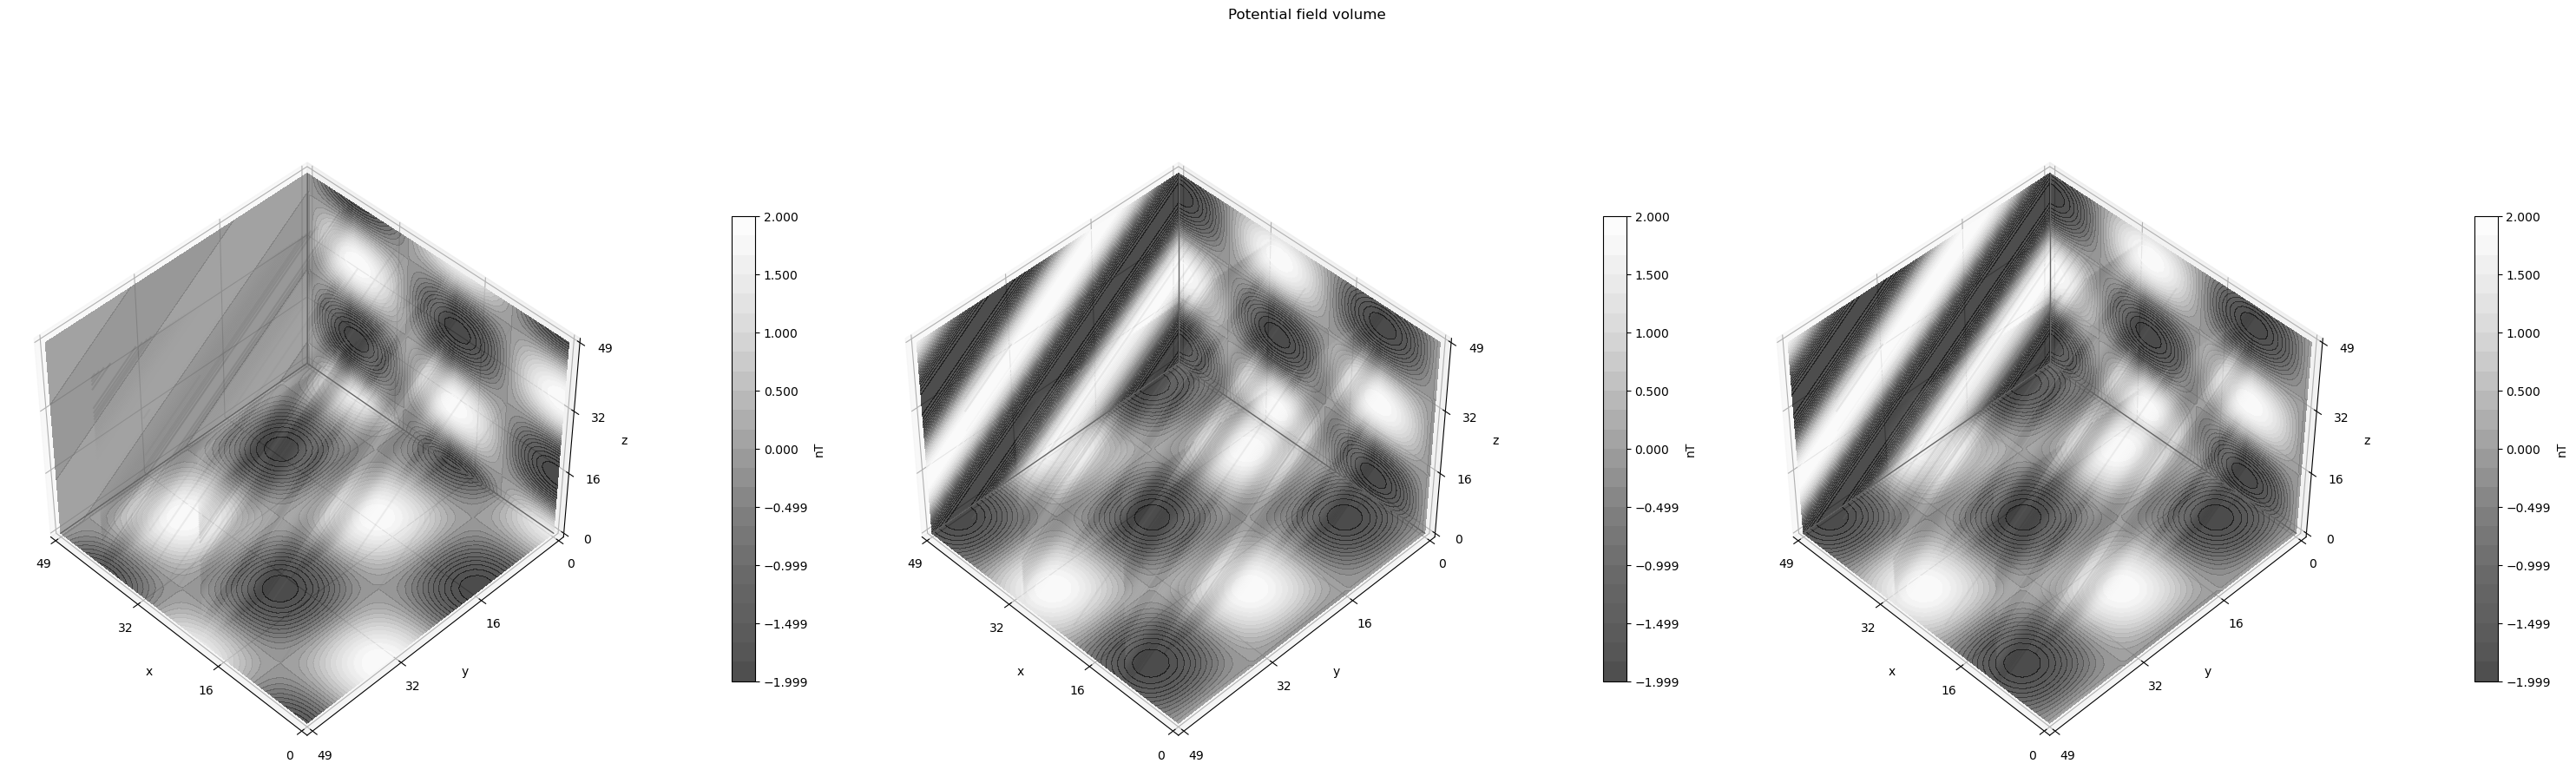

In [20]:
opts = dict(ori="x", step=10, elev=45, azim=135, linear_width=1, cmap=cc.cm.CET_L1)

fig = plt.figure(figsize=(30, 10), layout="constrained")
ax = fig.add_subplot(131, projection="3d")
plt_3d(dudx, **opts, ax=ax, fig=fig)
ax = fig.add_subplot(132, projection="3d")
plt_3d(dudy, **opts, ax=ax, fig=fig)
ax = fig.add_subplot(133, projection="3d")
plt_3d(dudz, **opts, ax=ax, fig=fig)
# plt_3d(dudx, **opts, ax=fig.add_subplot(234, projection="3d"))
# plt_3d(dudy, **opts, ax=fig.add_subplot(235, projection="3d"))
# plt_3d(dudz, **opts, ax=fig.add_subplot(236, projection="3d"))

# TODO

So we've established that an Implicit function such as SIREN can learn a grid extent quite well.  
Now we want to calculate the gradients (Jacobian) using the network.  
We do this as a calculation of the gradients between the model inputs (x,y) and the model output (u) which is the TMI at that x,y point.

There are several ways to calculate the Jacobian:  
1. `torch.autograd.grad`
1. `torch.autograd.functional.jacobian(vectorize=True)`
1. `functorch.jacrev`

https://github.com/pytorch/pytorch/issues/23475#issuecomment-946927242

We want the Jacobian: $$J(x,y) = [\frac{\partial{u(x,y)}}{\partial{x}}, \frac{\partial{u(x,y)}}{\partial{y}}]$$

Where $$ u = f(x,y)\,,\, f:R^2 \to R^1$$
This is the special case where _the Jacobian matrix reduces to the row vector $${\displaystyle \nabla ^{\mathrm {T} }f}$$ this row vector of all first-order partial derivatives of f is the transpose of the gradient of f $${\displaystyle \mathbf {J} _{f}=\nabla ^{T}f}. $$_



In [ ]:
def gradient(u, xyz, grad_outputs=None):
    if grad_outputs is None:
        grad_outputs = torch.ones_like(u)
    grad = torch.autograd.grad(u, [xyz], grad_outputs=grad_outputs, create_graph=True)[
        0
    ]
    return grad


def divergence(u, xyz):
    div = 0.0
    for i in range(u.shape[-1]):
        div += torch.autograd.grad(
            u[..., i], xyz, torch.ones_like(u[..., i]), create_graph=True
        )[0][..., i : i + 1]
    return div


def laplace(u, xyz):
    return divergence(gradient(u, xyz), xyz)


def s_jacobian(u, xyz):
    """jacobian of u wrt x"""
    meta_batch_size, num_observations = u.shape[:2]
    jac = torch.zeros(meta_batch_size, num_observations, u.shape[-1], xyz.shape[-1]).to(
        u.device
    )  # (meta_batch_size*num_points, 2, 2)
    for i in range(u.shape[-1]):
        # calculate dydx over batches for each feature value of y
        u_flat = u[..., i].view(-1, 1)
        jac[:, :, i, :] = torch.autograd.grad(
            u_flat, xyz, torch.ones_like(u_flat), create_graph=True
        )[0]

    status = 0
    if torch.any(torch.isnan(jac)):
        status = -1

    return jac, status

In [45]:
## Simple method for "Gradient", torch.autograd.grad
## The gradient is a special case of the Jacbian, when the function is scalar
## https://math.stackexchange.com/questions/1519367/difference-between-gradient-and-jacobian

netcdf_path = Path(
    "/home/luke/PhD/ch3/implicitgeo/data/P864-line-magnetic-AWAGS_MAG_2010.nc"
)
dataset = NCDataset(netcdf_path, "mag_microLevelled")
dataset.split_train_val(train_pct=0.8)

# d = dataset[0]
# train_xyz = d["train_xyz"].unsqueeze(0)
# train_u = d["train_u"].unsqueeze(0)

shape = (200,200,1)
query_xyz = construct_xyz((200,200,1), z_mod=-0.4)
query_xyz.requires_grad_(True)
query_xyz = query_xyz.to(device)
# train_u = train_u.to(device)


pred_u, query_xyz = inr(query_xyz)
pred_u = dataset.unnormalise(pred_u, var="u")
# model_input = dset._unnormalise(model_input)

grad = torch.autograd.grad(
    outputs=pred_u,
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(pred_u),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
# grad = [grad[0]]
# print(f"{grad[0].shape = }")

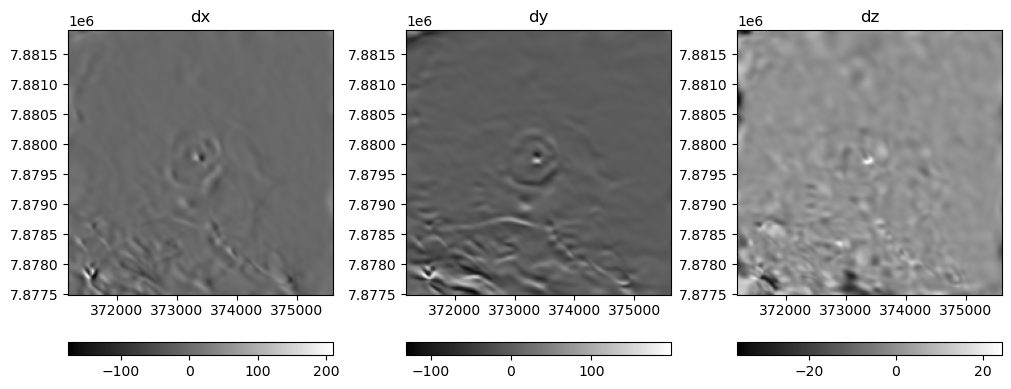

In [46]:
# First Derivative?
dx, dy, dz = grad[0].detach().cpu().squeeze().permute(1,0)

ax_args = dict(cmap=cc.cm.CET_L1, extent=extent)

plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("dx")
plt.imshow(dx.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 2)
plt.title("dy")
plt.imshow(dy.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 3)
plt.title("dz")
plt.imshow(dz.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")

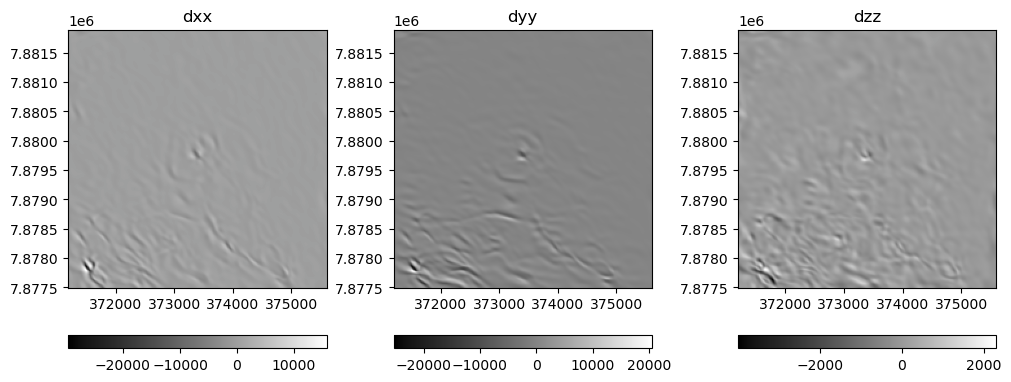

In [47]:
# Second Derivative?
grad2 = torch.autograd.grad(
    outputs=[grad[0]],
    inputs=[query_xyz],
    grad_outputs=torch.ones_like(grad[0]),
    create_graph=True,
    retain_graph=True,
    allow_unused=True,
)
dxx, dyy, dzz = grad2[0].detach().cpu().squeeze().permute(1,0)


plt.figure(constrained_layout=True, figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.title("dxx")
plt.imshow(dxx.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 2)
plt.title("dyy")
plt.imshow(dyy.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")
plt.subplot(1, 3, 3)
plt.title("dzz")
plt.imshow(dzz.view(shape[:2]).rot90().numpy(), **ax_args)
plt.colorbar(orientation="horizontal")

## TODO

TypeError: Invalid shape (50, 50, 50) for image data

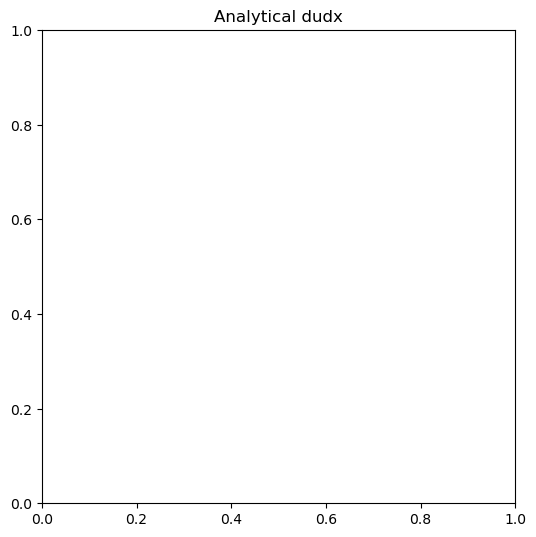

In [38]:
xmin = dudx.min()
xmax = dudx.max()
ymin = dudy.min()
ymax = dudy.max()

plt.figure(constrained_layout=True, figsize=(10, 10))
plt.subplot(221)
plt.title("Analytical dudx")
plt_cntr(dudx)
plt.subplot(222)
plt.title("Implicit dudx")
plt.imshow(dx, origin="lower", cmap=cc.cm.CET_L1, vmin=xmin, vmax=xmax)
plt.colorbar()
plt.subplot(223)
plt.title("Analytical dudy")
plt_cntr(dudy)
plt.subplot(224)
plt.title("Implicit dudy")
plt.imshow(dy, origin="lower", cmap=cc.cm.CET_L1, vmin=ymin, vmax=ymax)
plt.colorbar()

In [ ]:
def gradients(pred_u, xy_coord):
    """Compute the xx and yy gradients of the Implicit Function
    When trained, inputs of (x,y) coords to a Siren model (F) return u.
    Generally, this is u = F(x,y)
    """
    return (
        torch.autograd.grad(
            outputs=pred_u,
            inputs=[xy_coord],
            grad_outputs=torch.ones_like(pred_u),
            create_graph=True,
            retain_graph=True,
            allow_unused=True,
        )[0]
        .detach()
        .reshape(dset.s, dset.s, 2)
        .permute(2, 0, 1)
        .cpu()
        # .numpy()
    )


# Below references are per Blakely, R. J. 1996
# _Potential Theory in Gravity and Magnetic Applications_
# Cambridge University Press


def horizontal_gradient(dudy, dudx):
    """Horizontal Gradient, eqn 12.49"""
    # return torch.sqrt(dudx ** 2 + dudy ** 2)
    return torch.dstack((dudy, dudx)).norm(dim=-1, p="fro")


def upward_continuation():
    """Upward Continuation, eqn 12.4
    It would be interesting to include u in the coords, and predict this
    """
    # (dz / 2 * pi) * double integral (output_xyz0) / ((x-x')^2 + (y-y')^2 + (dz**2))**(3/2) dxdy

    return NotImplementedError


def downward_continuation(du):
    """Downward Continuation, eqn 12.5
    args:
        - du: vertical distance to downward continue



    """

    return NotImplementedError


def vertical_derivative(order=1):
    """Vertical Derivative, eqn 12.17
    Args:
        order (int): Order of derivative, e.g. 2 for 2VD

    """
    return NotImplementedError

In [ ]:
pred_u, xy_coord = img_siren(model_input)
dudy, dudx = gradients(pred_u, model_input)
horiz_g = horizontal_gradient(dudy, dudx)

In [ ]:
plt.imshow(horiz_g, cmap=cc.cm.CET_L1, origin="lower")
plt.title("Horizontal Gradient")

In [ ]:
crop = dset.original_shape
# w,e,s,n = (0, crop[-2], 0, crop[-1])
w, e, s, n = zoom

In [ ]:
import matplotlib.colors as colors

fig, axs = plt.subplots(3, 2, layout="constrained", figsize=(10, 12))
plt.suptitle(f"Horizontal Derivatives - {sample.stem}")
plt_opts = dict(origin="upper", cmap=cc.cm.CET_L1)
[[axg, axp], [axx, axy], [axh, axoff]] = axs

axg.set_title(r"Original TMI Grid")
caxi = axg.imshow(
    dset.original_grid.squeeze()[s:n, w:e], cmap=cc.cm.CET_L1, origin="lower"
)
plt.colorbar(mappable=caxi, ax=axg, label=r"nT", location="bottom")

axp.set_title(r"Learnt TMI Grid")
caxp = axp.imshow(
    pred_u.detach().cpu().view(dset.s, dset.s).squeeze()[s:n, w:e], cmap=cc.cm.CET_L1
)
plt.colorbar(mappable=caxp, ax=axp, label=r"nT", location="bottom")

axh.set_title(r"Horizontal gradient")
caxh = axh.imshow(horiz_g[s:n, w:e], cmap=cc.cm.CET_L1, vmin=0, vmax=10)
plt.colorbar(mappable=caxh, ax=axh, label=r"nT/cell", location="bottom")

axx.set_title(r"$\delta$u$\delta$x")
caxx = axx.imshow(dudx[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxx, ax=axx, label=r"nT/cell", location="bottom")

axy.set_title(r"$\delta$u$\delta$y")
caxy = axy.imshow(dudy[s:n, w:e], **plt_opts)  # , vmin=-8, vmax=8)
plt.colorbar(mappable=caxy, ax=axy, label=r"nT/cell", location="bottom")

# norm = colors.LogNorm(vmin=0.1, vmax=60)
axoff.axis("off")

for ax in axs.ravel():
    ax.set_xlabel("x")
    ax.set_ylabel("y")

In [ ]:
# ## SPARE BITS###


# # from functorch import vmap, vjp, jacrev

# # vmap(jacrev(img_siren))(model_input)
# ###

# j = (dudx, dudy) = torch.autograd.functional.jacobian(lambda t: img_siren(t), model_input)#, vectorize=True)
# ###

# ## Sitzmann et al. method (non vectorised)
# meta_batch_size = pred_u.shape[0]  # only 1 tile
# num_observations = pred_u.shape[1]  # Num XYZ points,
# out_vecs = pred_u.shape[-1]  # num output channels, 1
# in_ch = xy_coord.shape[-1]  # num input channels, 2

# jac = torch.zeros(meta_batch_size, num_observations, out_vecs, in_ch).to(
#     pred_u.device
# )  # (meta_batch_size*num_points, 2, 2)
# for vec in range(out_vecs):
#     # calculate dydx over batches for each feature value of y
#     y_flat = pred_u[..., vec].view(-1, 1)
#     jac[:, :, vec, :] = torch.autograd.grad(
#         y_flat, xy_coord, torch.ones_like(y_flat), create_graph=True
#     )[0]

# ###

# jac2 = jac.squeeze().reshape(200,200,2).permute(2,0,1)[1]
# plt.imshow(jac2.detach().cpu().numpy())
# plt.colorbar()
# ###


# from functorch import vmap, vjp, jacrev

# def f(x):
#     return img_siren(x)

# j = jacrev(f)(model_input.squeeze())

# print(model_input.squeeze().shape)
# print(f"{j[0].shape=}")
# print(f"{j[1].shape=}")

# ###

# ## As of pytorch 1.13, we can now use functorch operations
# ## https://pytorch.org/functorch/stable/notebooks/jacobians_hessians.html

# # from functorch import vmap, vjp, jacfwd, jacrev
# # torch.manual_seed(0)

# # img_siren

# # m = model_input.clone().requires_grad_()

# # cotangents = torch.eye(m.shape[1])
# # _, vjp_fn = vjp((img_siren), m)
# # vmap(vjp_fn)(cotangents)

# # # ft_jacobian = jacrev(img_siren, argnums=(0,))(m)

# # # ft_jacobian = vmap(jacrev(img_siren, argnums = 0), in_dims=(None, 0, None))
# # # btach_jac = ft_jacobian( )

# # model_output, coords = img_siren(model_input)
# # print(f"{model_input.shape=}")
# # print(f"{img_siren(model_input)[0].shape=}")
# # print(f"{img_siren(model_input)[1].shape=}")

# # j = torch.autograd.functional.jacobian(lambda x: img_siren(x)[0], model_input, vectorize=True)
# # j2 = torch.diagonal(j, offset=0, dim1=0, dim2=2)
# # j3 = j2.permute(2,0,1)

# # j2.shape
# # j.squeeze()[1].reshape(s, s, 2).shape